Sync Topic Model cumulative through 75-100: 0.94
Sync Topic Model cumulative through 50-75: 0.91
Sync Topic Model cumulative through 25-50: 0.86
Sync Topic Model cumulative through 0-25: 0.81
Async Topic Model cumulative through 75-100: 0.80
Async Topic Model cumulative through 50-75: 0.75
Async Topic Model cumulative through 25-50: 0.73
Async Topic Model cumulative through 0-25: 0.67
Sync LLM-based cumulative through 75-100: 0.68
Sync LLM-based cumulative through 50-75: 0.69
Sync LLM-based cumulative through 25-50: 0.66
Sync LLM-based cumulative through 0-25: 0.61
Async LLM-based cumulative through 75-100: 0.82
Async LLM-based cumulative through 50-75: 0.80
Async LLM-based cumulative through 25-50: 0.77
Async LLM-based cumulative through 0-25: 0.68
Sync Relational cumulative through 75-100: 0.61
Sync Relational cumulative through 50-75: 0.54
Sync Relational cumulative through 25-50: 0.51
Sync Relational cumulative through 0-25: 0.47
Async Relational cumulative through 75-100: 0.70
Asy

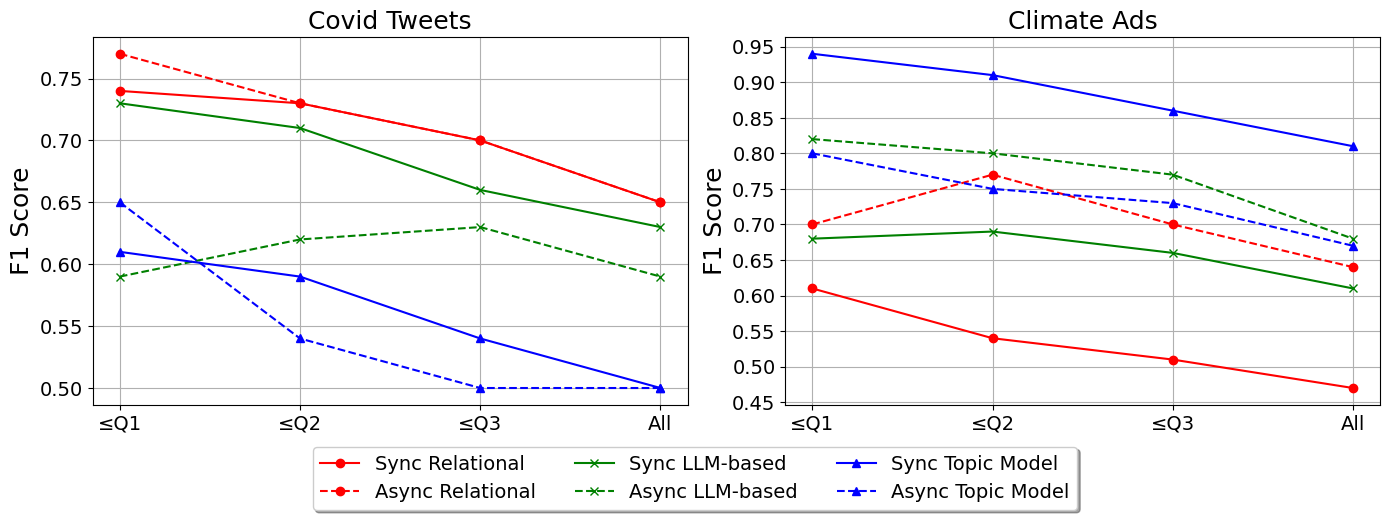

In [26]:
from sklearn.metrics import f1_score
import csv
import matplotlib.pyplot as plt

# --- Read data ---
root = './dataset/climate_ad_tiebreak.csv'
separated_data = {}
reader = csv.reader(open(root, 'r'))
next(reader)
for row in reader:
    if row[1]:
        bucket = f"{row[0]}_{row[1]}_{row[2]}"
        al = 0 if not row[6] else int(row[6])
        ro = 0 if not row[5] else int(row[5])
        ma = 0 if not row[8] else int(row[8])
        dj = 0 if not row[9] else int(row[9])
        separated_data.setdefault(bucket, []).append((al, ro, ma, dj))

# --- Cumulative F1 calculation ---
# 75-100 is closest to centroid; accumulate outward
systems = ["Fang", "LACA", "Pacheco"]
settings = ["Sync", "Async"]
quartiles_ordered = ["75-100", "50-75", "25-50", "0-25"]  # closest → furthest

def get_f1_score(groups):
    y, pred = [], []
    for group in groups:
        for line in separated_data[group]:
            y.append(1 if sum(line) == 2 else 0)
            pred.append(1)
    return f1_score(y, pred)

# Display name mapping
display_names = {"Fang": "Topic Model", "LACA": "LLM-based", "Pacheco": "Relational"}

results = {}
for system in systems:
    for setting in settings:
        label = f"{setting} {display_names[system]}"
        cumulative_groups = []
        f1s = []
        for q in quartiles_ordered:
            cumulative_groups.append(f"{system}_{setting}_{q}")
            f1 = get_f1_score(cumulative_groups)
            f1s.append(round(f1, 2))
            print(f"{label} cumulative through {q}: {f1:.2f}")
        results[label] = f1s

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Covid Tweets data
covid_data = {
    "Sync Relational": [0.74, 0.73, 0.70, 0.65],
    "Async Relational": [0.77, 0.73, 0.70, 0.65],
    "Sync LLM-based": [0.73, 0.71, 0.66, 0.63],
    "Async LLM-based": [0.59, 0.62, 0.63, 0.59],
    "Sync Topic Model": [0.61, 0.59, 0.54, 0.50],
    "Async Topic Model": [0.65, 0.54, 0.50, 0.50],
}

plot_order = [
    "Sync Relational", "Async Relational",
    "Sync LLM-based", "Async LLM-based",
    "Sync Topic Model", "Async Topic Model",
]
colors =      ['r', 'r', 'g', 'g', 'b', 'b']
line_styles = ['-', '--', '-', '--', '-', '--']
markers =     ['o', 'o', 'x', 'x', '^', '^']
x_labels = ["≤Q1", "≤Q2", "≤Q3", "All"]

# Plot Covid Tweets first (ax1)
for i, key in enumerate(plot_order):
    ax1.plot(x_labels, covid_data[key], label=key,
             color=colors[i], linestyle=line_styles[i], marker=markers[i])
ax1.set_title("Covid Tweets", fontsize=18)
ax1.set_ylabel("F1 Score", fontsize=18)
ax1.tick_params(labelsize=14)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax1.grid()

# Plot Climate Ads second (ax2)
for i, key in enumerate(plot_order):
    ax2.plot(x_labels, results[key], label=key,
             color=colors[i], linestyle=line_styles[i], marker=markers[i])
ax2.set_title("Climate Ads", fontsize=18)
ax2.set_ylabel("F1 Score", fontsize=18)
ax2.tick_params(labelsize=14)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax2.grid()

# Shared legend below both subplots
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=3, fontsize=14, fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

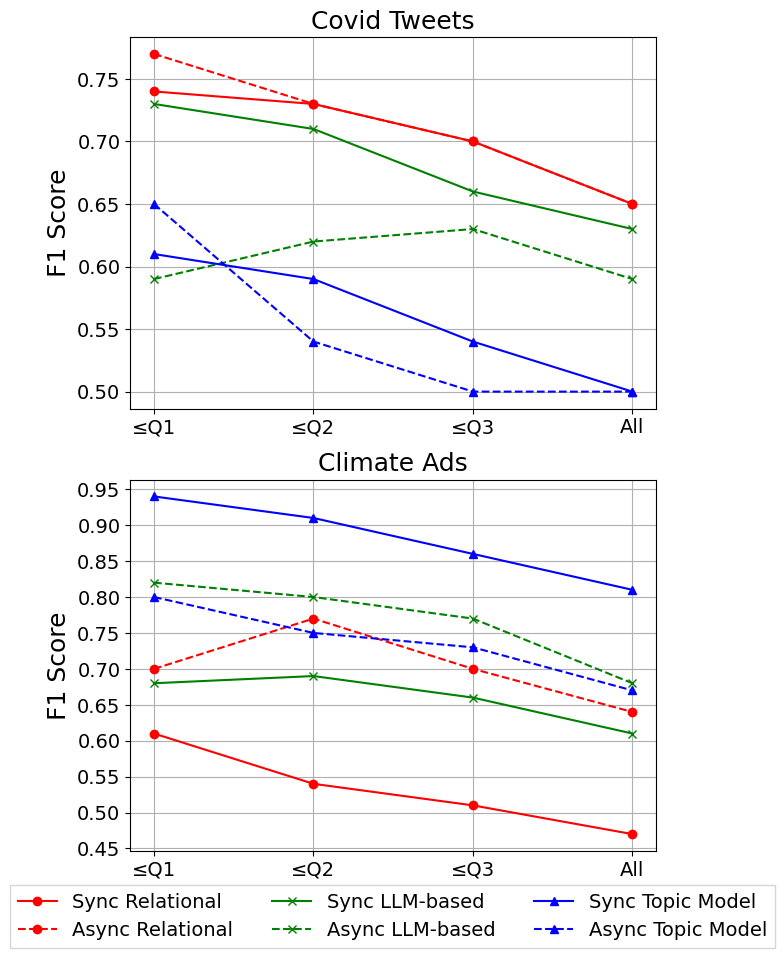

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))

# Covid Tweets on top
for i, key in enumerate(plot_order):
    ax1.plot(x_labels, covid_data[key], label=key,
             color=colors[i], linestyle=line_styles[i], marker=markers[i])
ax1.set_title("Covid Tweets", fontsize=18)
ax1.set_ylabel("F1 Score", fontsize=18)
ax1.tick_params(labelsize=14)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax1.grid()

# Climate Ads on bottom
for i, key in enumerate(plot_order):
    ax2.plot(x_labels, results[key], label=key,
             color=colors[i], linestyle=line_styles[i], marker=markers[i])
ax2.set_title("Climate Ads", fontsize=18)
ax2.set_ylabel("F1 Score", fontsize=18)
ax2.tick_params(labelsize=14)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax2.grid()

# Legend to the right, one entry per row
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.45, -0.07),
           ncol=3, fontsize=14, fancybox=False, shadow=False)

plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

In [1]:
from nltk.metrics.agreement import AnnotationTask
import csv

root = './dataset/climate_ad_tiebreak.csv'
outdir = './dataset/correctness'
separated_data = {}
all_tog = []
reader = csv.reader(open(root, 'r'))
next(reader)
for row in reader:
    bucket = row[0] + row[1] + row[2]
    al = 'NA' if not row[6] else row[6]
    ro = 'NA' if not row[5] else row[5]
    ma = 'NA' if not row[8] else row[8]
    dj = 'NA' if not row[9] else row[9]
    if bucket not in separated_data:
        separated_data[bucket] = [(al, ro, ma, dj)]
    else:
        separated_data[bucket].append((al, ro, ma, dj))
    all_tog.append((al, ro, ma, dj))

with open(f'{outdir}/all_tog.csv', 'w') as f:
    writer = csv.writer(f)
    for row in all_tog:
        writer.writerow(row)

In [2]:
import csv
from sklearn.metrics import f1_score

root = 'dataset/climate_ad_tiebreak.csv'
outdir = 'dataset/correctness'
separated_data = {}
reader = csv.reader(open(root, 'r'))
next(reader)
for row in reader:
    if row[1]:
        bucket = f"{row[0]}_{row[1]}_{row[2]}"
        al = 0 if not row[6] else int(row[6])
        ro = 0 if not row[5] else int(row[5])
        ma = 0 if not row[8] else int(row[8])
        dj = 0 if not row[9] else int(row[9])
        if bucket not in separated_data:
            separated_data[bucket] = [(al, ro, ma, dj)]
        else:
            separated_data[bucket].append((al, ro, ma, dj))
    else:
        continue
for k, v in separated_data.items():
    count = 0
    y = []
    pred = []
    for i in v:
        if sum(i) == 2:
            count += 1
            y.append(1)
        else:
            y.append(0)
        pred.append(1)
    print(k, count/50, f"{f1_score(y, pred):.2f}")

Fang_Async_0-25 0.3 0.46
Fang_Async_25-50 0.52 0.68
Fang_Async_50-75 0.54 0.70
Fang_Async_75-100 0.66 0.80
Fang_Sync_0-25 0.42 0.59
Fang_Sync_25-50 0.62 0.77
Fang_Sync_50-75 0.78 0.88
Fang_Sync_75-100 0.88 0.94
LACA_Async_0-25 0.18 0.31
LACA_Async_25-50 0.56 0.72
LACA_Async_50-75 0.62 0.77
LACA_Async_75-100 0.7 0.82
LACA_Sync_0-25 0.26 0.41
LACA_Sync_25-50 0.42 0.59
LACA_Sync_50-75 0.54 0.70
LACA_Sync_75-100 0.52 0.68
Pacheco_Async_0-25 0.28 0.44
Pacheco_Async_25-50 0.38 0.55
Pacheco_Async_50-75 0.7 0.82
Pacheco_Async_75-100 0.54 0.70
Pacheco_Sync_0-25 0.2 0.33
Pacheco_Sync_25-50 0.28 0.44
Pacheco_Sync_50-75 0.3 0.46
Pacheco_Sync_75-100 0.44 0.61


In [3]:
"Fang_Async_0-25"
"Fang_Async_25-50"
"Fang_Async_50-75"
"Fang_Async_75-100"
"Fang_Sync_0-25"
"Fang_Sync_25-50"
"Fang_Sync_50-75"
"Fang_Sync_75-100"
"LACA_Async_0-25"
"LACA_Async_25-50"
"LACA_Async_50-75"
"LACA_Async_75-100"
"LACA_Sync_0-25"
"LACA_Sync_25-50"
"LACA_Sync_50-75"
"LACA_Sync_75-100"
"Pacheco_Async_0-25"
"Pacheco_Async_25-50"
"Pacheco_Async_50-75"
"Pacheco_Async_75-100"
"Pacheco_Sync_0-25"
"Pacheco_Sync_25-50"
"Pacheco_Sync_50-75"
"Pacheco_Sync_75-100"

p_a_q1 = ["Pacheco_Async_0-25"]
p_a_q2 = ["Pacheco_Async_0-25", "Pacheco_Async_25-50"]
p_a_q3 = ["Pacheco_Async_0-25", "Pacheco_Async_25-50", "Pacheco_Async_50-75"]
p_a_q4 = ["Pacheco_Async_0-25", "Pacheco_Async_25-50", "Pacheco_Async_50-75", "Pacheco_Async_75-100"]
f_a_q1 = ["Fang_Async_0-25"]
f_a_q2 = ["Fang_Async_0-25", "Fang_Async_25-50"]
f_a_q3 = ["Fang_Async_0-25", "Fang_Async_25-50", "Fang_Async_50-75"]
f_a_q4 = ["Fang_Async_0-25", "Fang_Async_25-50", "Fang_Async_50-75", "Fang_Async_75-100"]
l_a_q1 = ["LACA_Async_75-100"]
l_a_q2 = ["LACA_Async_75-100", "LACA_Async_25-50"]
l_a_q3 = ["LACA_Async_75-100", "LACA_Async_25-50", "LACA_Async_50-75"]
l_a_q4 = ["LACA_Async_75-100", "LACA_Async_25-50", "LACA_Async_50-75", "LACA_Async_0-25"]
p_s_q1 = ["Pacheco_Sync_0-25"]
p_s_q2 = ["Pacheco_Sync_0-25", "Pacheco_Sync_25-50"]
p_s_q3 = ["Pacheco_Sync_0-25", "Pacheco_Sync_25-50", "Pacheco_Sync_50-75"]
p_s_q4 = ["Pacheco_Sync_0-25", "Pacheco_Sync_25-50", "Pacheco_Sync_50-75", "Pacheco_Sync_75-100"]
f_s_q1 = ["Fang_Sync_0-25"]
f_s_q2 = ["Fang_Sync_0-25", "Fang_Sync_25-50"]
f_s_q3 = ["Fang_Sync_0-25", "Fang_Sync_25-50", "Fang_Sync_50-75"]
f_s_q4 = ["Fang_Sync_0-25", "Fang_Sync_25-50", "Fang_Sync_50-75", "Fang_Sync_75-100"]
l_s_q1 = ["LACA_Sync_75-100"]
l_s_q2 = ["LACA_Sync_75-100", "LACA_Sync_25-50"]
l_s_q3 = ["LACA_Sync_75-100", "LACA_Sync_25-50", "LACA_Sync_50-75"]
l_s_q4 = ["LACA_Sync_75-100", "LACA_Sync_25-50", "LACA_Sync_50-75", "LACA_Sync_0-25"]

pacheco = {"async": [p_a_q1, p_a_q2, p_a_q3, p_a_q4], "sync": [p_s_q1, p_s_q2, p_s_q3, p_s_q4]}
fang = {"async": [f_a_q1, f_a_q2, f_a_q3, f_a_q4], "sync": [f_s_q1, f_s_q2, f_s_q3, f_s_q4]}
laca = {"async": [l_a_q1, l_a_q2, l_a_q3, l_a_q4], "sync": [l_s_q1, l_s_q2, l_s_q3, l_s_q4]}


def get_f1_score(data, separated_data):
    full_set = []
    for group in data:
        full_set.extend(separated_data[group])
    count = 0
    y = []
    pred = []
    for line in full_set:
        if sum(line) == 2:
            count += 1
            y.append(1)
        else:
            y.append(0)
        pred.append(1)
    print(f"{f1_score(y, pred):.2f}")

for key in laca:
    for q in laca[key]:
        print(f"laca {key} {q}")
        get_f1_score(q, separated_data)

laca async ['LACA_Async_75-100']
0.82
laca async ['LACA_Async_75-100', 'LACA_Async_25-50']
0.77
laca async ['LACA_Async_75-100', 'LACA_Async_25-50', 'LACA_Async_50-75']
0.77
laca async ['LACA_Async_75-100', 'LACA_Async_25-50', 'LACA_Async_50-75', 'LACA_Async_0-25']
0.68
laca sync ['LACA_Sync_75-100']
0.68
laca sync ['LACA_Sync_75-100', 'LACA_Sync_25-50']
0.64
laca sync ['LACA_Sync_75-100', 'LACA_Sync_25-50', 'LACA_Sync_50-75']
0.66
laca sync ['LACA_Sync_75-100', 'LACA_Sync_25-50', 'LACA_Sync_50-75', 'LACA_Sync_0-25']
0.61


In [4]:
q1 = ["0-25"]
q2 = ["0-25", "25-50"]
q3 = ["0-25", "25-50", "50-75"]
q4 = ["0-25", "25-50", "50-75", "75-100"]
get_f1_score(q1, separated_data)
get_f1_score(q2, separated_data)
get_f1_score(q3, separated_data)
get_f1_score(q4, separated_data)

KeyError: '0-25'

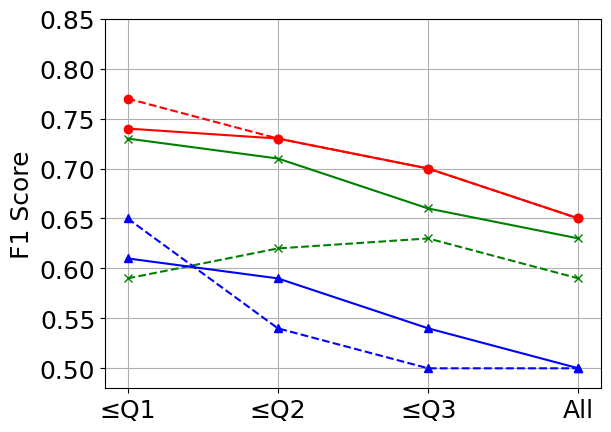

In [22]:
import matplotlib.pyplot as plt

all_dict = {"Sync Topic Model": [0.61, 0.59, 0.54, 0.50],
            "Sync Relational": [0.74, 0.73, 0.70, 0.65],
            "Sync LLM-based": [0.73, 0.71, 0.66, 0.63],
            "Async Topic Model": [0.65, 0.54, 0.50, 0.50],
            "Async Relational": [0.77, 0.73, 0.70, 0.65],
            "Async LLM-based": [0.59, 0.62, 0.63, 0.59]}

all_list = [["Sync Relational", [0.74, 0.73, 0.70, 0.65]],
            ["Async Relational", [0.77, 0.73, 0.70, 0.65]],
            ["Sync LLM-based", [0.73, 0.71, 0.66, 0.63]],
            ["Async LLM-based", [0.59, 0.62, 0.63, 0.59]],
            ["Sync Topic Model", [0.61, 0.59, 0.54, 0.50]], 
            ["Async Topic Model", [0.65, 0.54, 0.50, 0.50]]]

colors = ['r', 'r', 'g', 'g', 'b', 'b']
line_style = ['-', '--', '-', '--', '-', '--']
marker = ['o', 'o', 'x', 'x', '^', '^']

fig, ax = plt.subplots()
for i, key in enumerate(all_list):
    ax.plot(["≤Q1", "≤Q2", "≤Q3", "All"], key[1], label=key[0], color=colors[i], linestyle=line_style[i], marker=marker[i])
# ax.legend()
ax.set_ylim(0.48, 0.85)
ax.set_ylabel("F1 Score", fontsize=18)
#font size
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.legend(fontsize=18)
# # Shrink current axis's height by 10% on the bottom
# box = ax.get_position()
# ax.set_position([box.x0, box.y0 + box.height * 0.2,
#                  box.width, box.height * 0.8])

# Put a legend below current axis
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
#           fancybox=True, shadow=True, ncol=3, fontsize=18)

plt.grid()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_json("dataset/fang_system/alvin_processed.json")
df

,tweet_id,text,theme_id,name,weight
0,5272,"Now that the 2021 Primary is over, it is on to...",0,AntiGunBan,33.23
1,5260,"Virginia Patriots,\n\nOver the past 8 months w...",0,AntiGunBan,31.85
2,5261,"Will you stand and fight, or kneel and cower?\...",0,AntiGunBan,31.83
3,5265,"Fellow Patriots,\n\nOn November 2nd, Virginia ...",0,AntiGunBan,31.60
4,5254,"Patriots,\n\nThank you. \n\nDue to your donati...",0,AntiGunBan,31.18
...,...,...,...,...,...
87507,713,"It’s not always easy to do the right thing, bu...",15,OilTheft,1.89
87508,718,"It’s not always easy to do the right thing, bu...",15,OilTheft,1.88
87509,720,"It’s not always easy to do the right thing, bu...",15,OilTheft,1.85
87510,4899,Meredith Brinegar is running for Bellbrook Cit...,15,OilTheft,1.81
